# Phase 4 — Output

**Goal:**
- An annotated output video with bounding boxes, persistent track IDs, visible zone overlays, and live occupancy count per zone
- A structured summary of the final per-zone analytics
- A frame-by-frame occupancy log


In [1]:
import cv2
import numpy as np
import json
import os
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm

INPUT_VIDEO_PATH  = Path(os.environ.get('INPUT_VIDEO_PATH', '../vidp.mp4'))
TRACKS_ZONED_PATH = Path('../outputs/analytics/tracks_with_zones.json')
ZONES_JSON_PATH   = Path('../outputs/analytics/zones.json')
ANALYTICS_JSON    = Path('../outputs/analytics/zone_analytics.json')
OUTPUT_FINAL_VIDEO = Path('../outputs/videos/final_annotated.mp4')
OUTPUT_FINAL_VIDEO.parent.mkdir(parents=True, exist_ok=True)

for p in [TRACKS_ZONED_PATH, ZONES_JSON_PATH]:
    assert p.exists(), f'Run prior phases first — missing: {p}'

with open(TRACKS_ZONED_PATH) as f:
    data = json.load(f)

with open(ZONES_JSON_PATH) as f:
    zones_list = json.load(f)

FPS    = data['metadata']['fps']
tracks = data['tracks']
zones  = {z['id']: z for z in zones_list}

print(f'✅ Loaded {len(tracks)} tracks, {len(zones)} zones')
print(f'   Input:  {INPUT_VIDEO_PATH}')
print(f'   Output: {OUTPUT_FINAL_VIDEO}')

✅ Loaded 66 tracks, 4 zones
   Input:  ..\vidp.mp4
   Output: ..\outputs\videos\final_annotated.mp4


In [2]:
frame_tracks    = defaultdict(list)
frame_occupancy = defaultdict(lambda: defaultdict(int))

for tid, records in tqdm(tracks.items(), desc='Building lookup'):
    for rec in records:
        fi = rec['frame']
        frame_tracks[fi].append({
            'tid'       : int(tid),
            'bbox'      : rec['bbox'],
            'zone_id'   : rec['zone_id'],
            'zone_name' : rec['zone_name'],
            'centroid'  : rec['centroid'],
            'foot_pos'  : rec.get('foot_pos', rec['centroid'])
        })
        if rec['zone_id'] is not None:
            frame_occupancy[fi][rec['zone_id']] += 1

print(f'✅ Lookup tables built for {len(frame_tracks)} frames.')

Building lookup:   0%|          | 0/66 [00:00<?, ?it/s]

✅ Lookup tables built for 339 frames.


In [3]:
PALETTE = [
    (255,  56,  56), (255, 157,  51), (255, 221,  51), ( 51, 255, 153),
    ( 51, 208, 255), ( 51,  80, 255), (153,  51, 255), (255,  51, 255),
    (255, 153, 204), (128, 255,   0), (  0, 255, 255), (255, 128,   0),
]

def track_color(tid: int) -> tuple:
    return PALETTE[tid % len(PALETTE)]


def draw_zones_overlay(frame: np.ndarray, zones: dict, alpha: float = 0.20) -> np.ndarray:
    overlay = frame.copy()
    
    for zid, zone in zones.items():
        pts   = np.array(zone['points'], dtype=np.int32)
        color = tuple(zone['color'])
        
        cv2.fillPoly(overlay, [pts], color)
    
    cv2.addWeighted(overlay, alpha, frame, 1 - alpha, 0, frame)
    
    for zid, zone in zones.items():
        pts   = np.array(zone['points'], dtype=np.int32)
        color = tuple(zone['color'])
        name  = zone['name']
        
        cv2.polylines(frame, [pts], isClosed=True, color=color, thickness=2)
        
        cx = int(np.mean([p[0] for p in zone['points']]))
        cy = int(np.mean([p[1] for p in zone['points']])) - 15
        (tw, th), _ = cv2.getTextSize(name, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
        cv2.rectangle(frame, (cx - tw//2 - 3, cy - th - 3),
                      (cx + tw//2 + 3, cy + 4), (0, 0, 0), -1)
        cv2.putText(frame, name, (cx - tw//2, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2)
    
    return frame

def draw_track_boxes(frame: np.ndarray, track_list: list) -> np.ndarray:
    for t in track_list:
        tid   = t['tid']
        color = track_color(tid)
        x1, y1, x2, y2 = t['bbox']
        
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        
        label = f'ID:{tid}'
        if t['zone_name'] and t['zone_name'] != 'Transit':
            label += f' [{t["zone_name"][:3]}]'
        
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
        cv2.rectangle(frame, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
        cv2.putText(frame, label, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

        fx, fy = t['foot_pos']
        cv2.circle(frame, (fx, fy), 4, color, -1)
        cv2.circle(frame, (fx, fy), 6, (255, 255, 255), 1)
    
    return frame


def draw_hud(frame: np.ndarray, frame_idx: int, fps: float,
             occupancy: dict, zones: dict, total_active: int) -> np.ndarray:
    ts      = frame_idx / fps
    minutes = int(ts // 60)
    seconds = ts % 60
    time_str = f'{minutes:02d}:{seconds:05.2f}'
    
    H, W = frame.shape[:2]
    
    panel_w = 220
    panel_h = 28 + len(zones) * 26 + 30
    px, py  = W - panel_w - 10, 10
    cv2.rectangle(frame, (px - 5, py - 5),
                  (px + panel_w, py + panel_h), (0, 0, 0), -1)
    cv2.rectangle(frame, (px - 5, py - 5),
                  (px + panel_w, py + panel_h), (80, 80, 80), 1)
    
    cv2.putText(frame, f'{time_str}  F:{frame_idx}',
                (px, py + 16), cv2.FONT_HERSHEY_SIMPLEX, 0.52,
                (200, 200, 200), 1)
    
    y_offset = py + 38
    for zid, zone in zones.items():
        count = occupancy.get(zid, 0)
        color = tuple(zone['color'])
        name  = zone['name'][:14].ljust(14)
        cv2.circle(frame, (px + 8, y_offset - 4), 5, color, -1)
        cv2.putText(frame, f'{name}: {count}',
                    (px + 20, y_offset),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.50, (220, 220, 220), 1)
        y_offset += 26
    
    cv2.putText(frame, f'TOTAL ACTIVE: {total_active}',
                (px, y_offset + 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.52, (255, 255, 100), 2)
    
    return frame

print('✅ Annotation engine defined.')

✅ Annotation engine defined.


In [4]:
import time

cap = cv2.VideoCapture(str(INPUT_VIDEO_PATH))
if not cap.isOpened():
    raise FileNotFoundError(f'Cannot open video: {INPUT_VIDEO_PATH}')

FW    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
FH    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS_V = cap.get(cv2.CAP_PROP_FPS) or FPS
TOTAL = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0

if FPS_V <= 0:
    cap.release()
    raise ValueError(f'Invalid FPS for video: {INPUT_VIDEO_PATH}')

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(str(OUTPUT_FINAL_VIDEO), fourcc, FPS_V, (FW, FH))
if not writer.isOpened():
    cap.release()
    raise RuntimeError('Could not open video writer. Try a different codec or check output path permissions.')

frame_idx  = 0
start_time = time.time()

try:
    with tqdm(total=TOTAL, desc='Rendering final video', unit='frame') as pbar:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame = draw_zones_overlay(frame, zones, alpha=0.18)
            track_list = frame_tracks.get(frame_idx, [])
            frame = draw_track_boxes(frame, track_list)
            occ          = dict(frame_occupancy.get(frame_idx, {}))
            total_active = len(track_list)
            frame = draw_hud(frame, frame_idx, FPS_V, occ, zones, total_active)

            writer.write(frame)
            frame_idx += 1
            pbar.update(1)
finally:
    cap.release()
    writer.release()

elapsed = time.time() - start_time
print(f'\n✅ Final video rendered in {elapsed:.1f}s ({elapsed/60:.1f}min)')
print(f'   Output: {OUTPUT_FINAL_VIDEO}')

Rendering final video:   0%|          | 0/341 [00:00<?, ?frame/s]


✅ Final video rendered in 10.1s (0.2min)
   Output: ..\outputs\videos\final_annotated.mp4


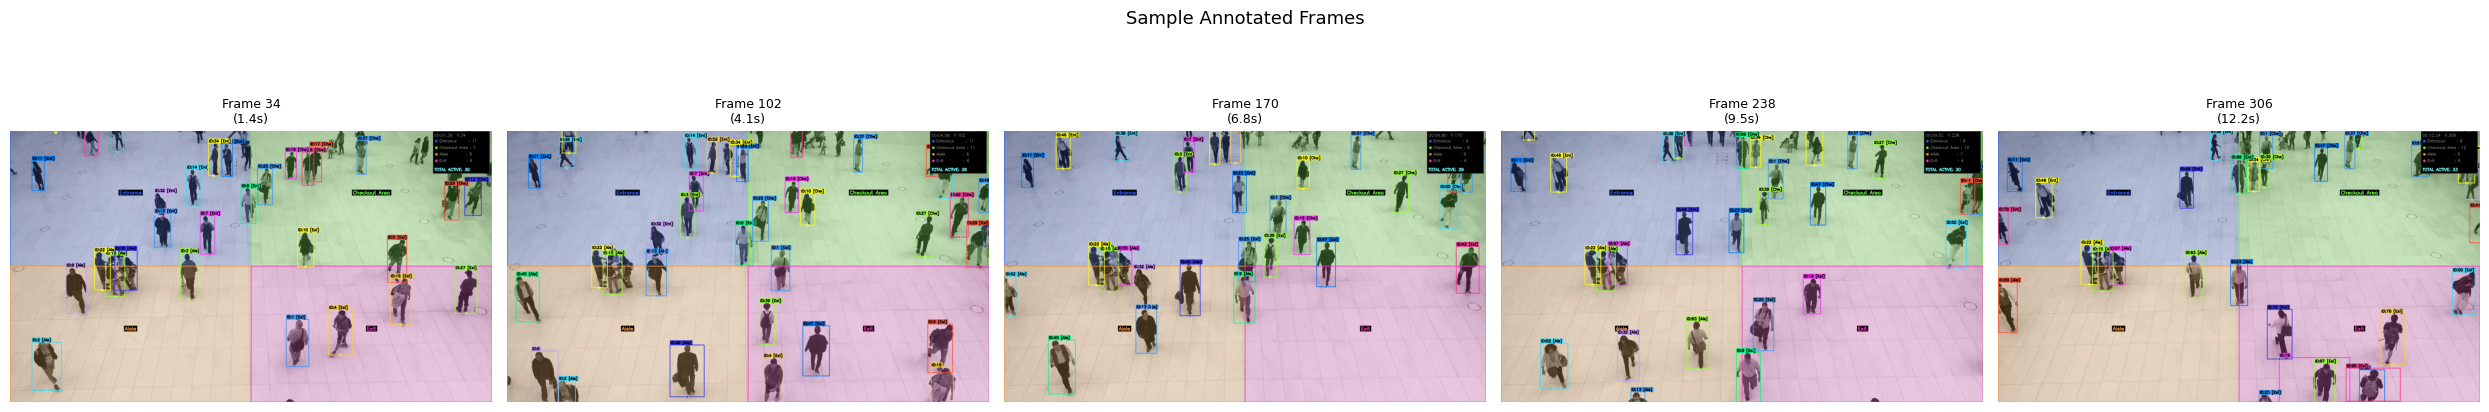

✅ Sample frames saved: outputs/analytics/sample_annotated_frames.png


In [5]:
import matplotlib.pyplot as plt

sample_dir = Path('../outputs/analytics')

cap = cv2.VideoCapture(str(OUTPUT_FINAL_VIDEO))
if not cap.isOpened():
    raise FileNotFoundError(f'Cannot open annotated video: {OUTPUT_FINAL_VIDEO}')

TOT = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
if TOT <= 0:
    cap.release()
    raise ValueError(f'Annotated video has no readable frames: {OUTPUT_FINAL_VIDEO}')

sample_frames_idx = [int(TOT * p) for p in [0.1, 0.3, 0.5, 0.7, 0.9]]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, fi in zip(axes, sample_frames_idx):
    cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
    ret, frame = cap.read()
    if ret:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Frame {fi}\n({fi/FPS_V:.1f}s)', fontsize=9)
    else:
        ax.set_title(f'Frame {fi}\n(unavailable)', fontsize=9)
    ax.axis('off')

cap.release()

plt.suptitle('Sample Annotated Frames', fontsize=13)
plt.tight_layout()
plt.savefig(str(sample_dir / 'sample_annotated_frames.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sample frames saved: outputs/analytics/sample_annotated_frames.png')

In [6]:
from pathlib import Path

required_phase4_outputs = [
    ('Video', '../outputs/videos/final_annotated.mp4', 'Final annotated video (Phase 4)'),
    ('Image', '../outputs/analytics/sample_annotated_frames.png', 'Sample frames from final video'),
]

required_inputs = [
    ('JSON', '../outputs/analytics/tracks_with_zones.json', 'Track data with zone assignments'),
    ('JSON', '../outputs/analytics/zones.json', 'Zone polygon definitions'),
    ('JSON', '../outputs/analytics/zone_analytics.json', 'Full analytics with epochs'),
    ('CSV', '../outputs/analytics/zone_analytics.csv', 'Per-zone summary table'),
    ('CSV', '../outputs/analytics/frame_occupancy_log.csv', 'Frame-by-frame occupancy log'),
    ('Image', '../outputs/analytics/first_frame.png', 'Reference first frame'),
    ('Image', '../outputs/analytics/zone_layout.png', 'Zone layout diagram'),
    ('Image', '../outputs/analytics/zone_heatmaps.png', 'Centroid heatmaps by zone'),
    ('Image', '../outputs/analytics/analytics_summary.png', '5-panel analytics charts'),
    ('Image', '../outputs/analytics/phase1_track_stats.png', 'Track duration statistics'),
]

print('=== PHASE 4 OUTPUTS ===')
print(f'{"Type":<8} {"Path":<55} {"Status":<6} Description')
print('-'*100)
all_ok = True
for dtype, path, desc in required_phase4_outputs + required_inputs:
    p = Path(path)
    exists = p.exists()
    size   = f'{p.stat().st_size / 1024:.0f}KB' if exists else '---'
    status = '✅' if exists else '❌'
    if not exists and (dtype, path, desc) in required_phase4_outputs:
        all_ok = False
    print(f'{dtype:<8} {path:<55} {status} ({size:<7}) {desc}')

print()
print('✅ Phase 4 outputs present!' if all_ok else '❌ Phase 4 outputs missing — check the rows above')

=== PHASE 4 OUTPUTS ===
Type     Path                                                    Status Description
----------------------------------------------------------------------------------------------------
Video    ../outputs/videos/final_annotated.mp4                   ✅ (25606KB) Final annotated video (Phase 4)
Image    ../outputs/analytics/sample_annotated_frames.png        ✅ (1463KB ) Sample frames from final video
JSON     ../outputs/analytics/tracks_with_zones.json             ✅ (3944KB ) Track data with zone assignments
JSON     ../outputs/analytics/zones.json                         ✅ (1KB    ) Zone polygon definitions
JSON     ../outputs/analytics/zone_analytics.json                ✅ (14KB   ) Full analytics with epochs
CSV      ../outputs/analytics/zone_analytics.csv                 ✅ (0KB    ) Per-zone summary table
CSV      ../outputs/analytics/frame_occupancy_log.csv            ✅ (6KB    ) Frame-by-frame occupancy log
Image    ../outputs/analytics/first_frame.png       